In [1]:
from mly.datatools import DataPod, DataSet, generator

# Python packages that we will need
import os

import matplotlib.pyplot as plt
# Setting a proper plotting format
%matplotlib inline
from math import ceil

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pycbc.pnutils as ut
from pycbc.waveform import get_td_waveform
from pycbc.waveform import get_fd_waveform
from pycbc.detector import Detector
from scipy import signal

import numpy as np
from gwpy.timeseries import TimeSeries as gwTS

from mly.projectwave import *
from mly.exceptions import *
from mly.plugins import *
from mly.waveforms import *
import sys
from mly.datatools import *
from mly.tools import toCategorical

import time ,os
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense,Conv1D, MaxPool1D, Flatten, Input ,Activation
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint ,ReduceLROnPlateau
from tensorflow.keras import optimizers, initializers
from tensorflow.config import threading
from tensorflow.keras.layers import GlobalAveragePooling2D
from mly.tools import correlate 

/home/edoardo.micheletti/.conda/envs/mly-base/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
2026-08-26 06:28:05.149687: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-

In [2]:
parts = [np.load(f'//home/edoardo.micheletti/model_tutorials/Models/C_grams/C_grams_slides/C_gram{i}.npy') for i in range(10)]

C_gram_noise = np.concatenate(parts,axis =0 )

In [3]:
np.shape(C_gram_noise)

(90000, 29, 60, 3)

In [4]:
model = load_model('/home/edoardo.micheletti/model_tutorials/Models/Saved_models/3BranchQui.keras',safe_mode=False)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 29, 60, 3)]          0         []                            
                                                                                                  
 lambda (Lambda)             (None, 29, 60, 1)            0         ['input_1[0][0]']             
                                                                                                  
 lambda_1 (Lambda)           (None, 29, 60, 1)            0         ['input_1[0][0]']             
                                                                                                  
 lambda_2 (Lambda)           (None, 29, 60, 1)            0         ['input_1[0][0]']             
                                                                                            

In [22]:
scores = model.predict( C_gram_noise)

2813/2813 [==============================] - 17s 6ms/step


In [23]:
scores = scores[:,1]

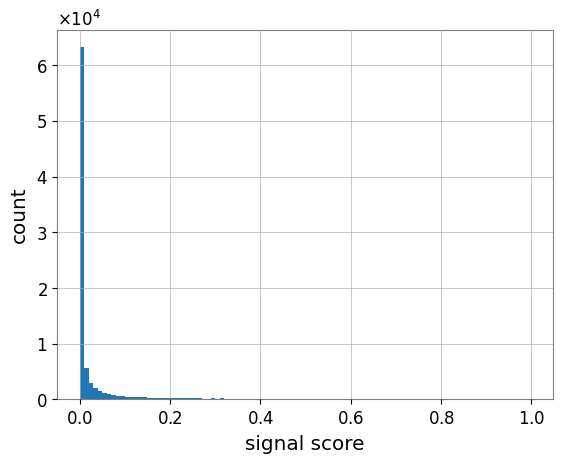

highest score: 0.9987043


In [7]:
plt.hist(scores, bins=100)
plt.xlabel('signal score')
plt.ylabel('count')
#plt.yscale('log')


plt.show()


print('highest score:', scores.max())

In [9]:
for t in [0.2, 0.5,0.7, 0.9, 0.99]:
    print(f'threshold {t}: FAR = {(scores > t).mean():.4f}  ({(scores > t).sum()} instances) ')

threshold 0.2: FAR = 0.0806  (7251 instances) 
threshold 0.5: FAR = 0.0376  (3385 instances) 
threshold 0.7: FAR = 0.0219  (1967 instances) 
threshold 0.9: FAR = 0.0079  (714 instances) 
threshold 0.99: FAR = 0.0006  (55 instances) 


In [14]:
sorted_scores = np.sort(scores)[::-1]

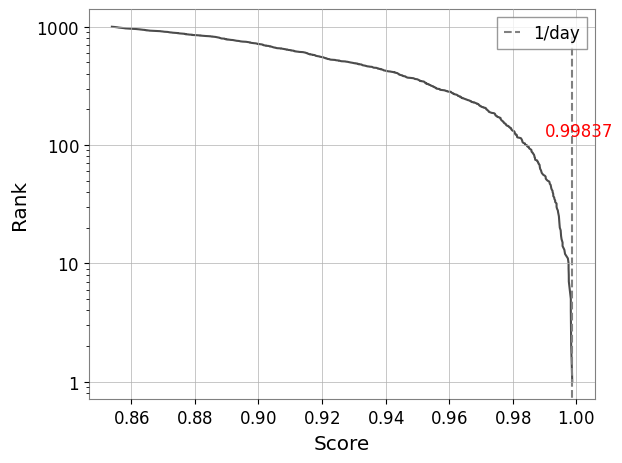

In [15]:
sorted_scores_1000 = sorted_scores[:1000]
rank = np.arange(1, len(sorted_scores_1000)+1)


plt.plot(sorted_scores_1000,rank,alpha = 0.7, color = 'black')
plt.yscale('log')
plt.ylabel('Rank')
plt.xlabel('Score')
plt.vlines(x = 0.9987043, ymin =0, ymax =1000, color = 'grey', linestyle ='--',label = '1/day')

plt.text(0.99,120,'0.99837', color = 'r',)
plt.legend()
plt.tight_layout()
plt.show()



In [10]:
arranged_scores = np.sort(scores)
print('Highest 10 scores', arranged_scores[-10:])

Highest 10 scores [0.997547   0.997547   0.99760747 0.9976252  0.9978982
 0.9982521  0.9982521  0.99829715 0.99836844 0.9987043 ]


In [27]:
far_per_day = 1.0                     
n_days = (len(scores) * 4) / 86400      
n_allowed = n_days * far_per_day
frac = n_allowed / len(scores)
threshold = np.percentile(scores, (1 - frac) * 100)
    
print(threshold)

0.9981931313789523


In [29]:
print(n_days)

4.166666666666667


In [30]:
efficiency = []
for snr in range(8,33):
    C_gram = np.load(f'/home/edoardo.micheletti/model_tutorials/Models/C_grams/900-BNS-{snr}SNR-4seconds-COGRAM.npy')
    preds = model.predict(C_gram)
    scores = preds[:,1]
    eff = (scores > threshold).mean()
    efficiency.append(eff)
    print(f'  SNR = {snr}, threshold = {threshold:.5f}, efficiency = {eff:.5f} ({(scores > threshold).sum()} instances)')
    if snr == 32:
        print('Job done')


32/32 [==============================] - 0s 6ms/step
  SNR = 8, threshold = 0.99819, efficiency = 0.00000 (0 instances)
10/32 [========>.....................] - ETA: 0s

32/32 [==============================] - 0s 6ms/step
  SNR = 9, threshold = 0.99819, efficiency = 0.00200 (2 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 10, threshold = 0.99819, efficiency = 0.00400 (4 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 11, threshold = 0.99819, efficiency = 0.00200 (2 instances)
32/32 [==============================] - 0s 5ms/step
  SNR = 12, threshold = 0.99819, efficiency = 0.00400 (4 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 13, threshold = 0.99819, efficiency = 0.02700 (27 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 14, threshold = 0.99819, efficiency = 0.04100 (41 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 15, threshold = 0.99819, efficiency = 0.09600 (96 instances)
32/32 [==============================] - 0s 6ms/step
  SNR = 16, threshold = 0.99819, efficiency = 0.13200 (132 instances)
32/32 [=====================

In [ ]:

import matplotlib
matplotlib.rcParams.update({'font.size': 13.5})


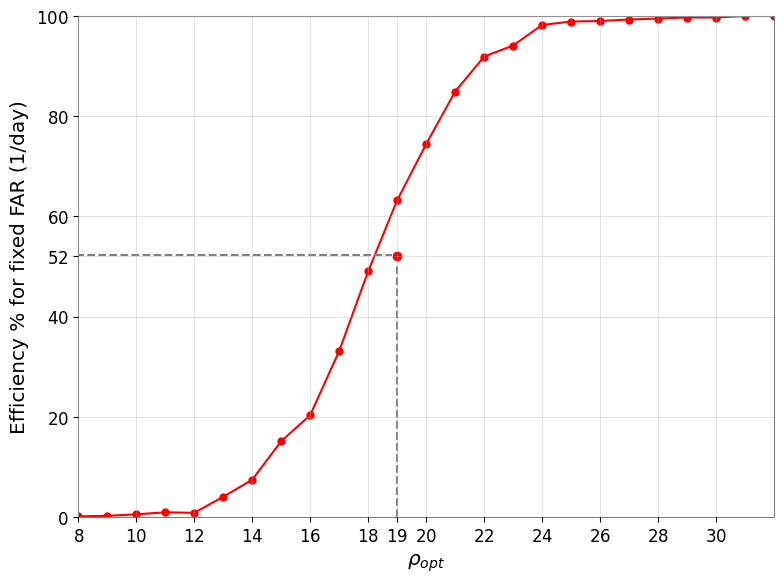

In [19]:
snr = np.arange(8,33,1)
eff = np.array(efficiency)
plt.figure(figsize = (8,6))
plt.plot(snr, eff*100, markersize = 5, marker = 'o',color = 'r' )
plt.plot(19,52,'ro')
plt.xlabel(r'$ \rho_{opt} $' )
plt.ylabel('Efficiency % for fixed FAR (1/day)')
plt.xticks(list(np.arange(8,32,2))+[19])
plt.yticks(list(np.arange(0,101,20))+[52])
plt.vlines(x = 19., ymin = 0, ymax = 50,colors = 'gray',linestyles='dashed')
plt.hlines(y = 52.2, xmin = 0 ,xmax = 18.835,colors = 'gray',linestyles = 'dashed')
plt.xlim(8,32)
plt.ylim(0,100)
plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()


In [14]:
idx = np.where(scores > 0.70)[0]
for i in idx:
    peaks = [np.abs(C_gram_noise[i][:,:,c]).max() for c in range(3)]  # HL, HV, LV
    print(i, [f'{p:.2f}' for p in peaks])

0 ['0.16', '0.14', '0.15']
1 ['0.16', '0.15', '0.15']
2 ['0.15', '0.18', '0.17']
3 ['0.14', '0.17', '0.21']
4 ['0.18', '0.16', '0.18']
5 ['0.16', '0.17', '0.18']
6 ['0.16', '0.15', '0.14']
7 ['0.15', '0.14', '0.15']
8 ['0.14', '0.14', '0.15']
9 ['0.14', '0.14', '0.16']
10 ['0.17', '0.20', '0.15']
11 ['0.15', '0.15', '0.15']
12 ['0.16', '0.18', '0.16']
13 ['0.16', '0.16', '0.16']
14 ['0.16', '0.15', '0.15']
15 ['0.16', '0.13', '0.18']
16 ['0.18', '0.14', '0.16']
17 ['0.14', '0.18', '0.15']
18 ['0.15', '0.16', '0.18']
19 ['0.15', '0.17', '0.15']
20 ['0.14', '0.15', '0.17']
21 ['0.15', '0.18', '0.16']
22 ['0.20', '0.17', '0.15']
23 ['0.15', '0.14', '0.17']
24 ['0.14', '0.15', '0.16']
25 ['0.16', '0.16', '0.16']
26 ['0.15', '0.15', '0.15']
27 ['0.16', '0.14', '0.15']
28 ['0.14', '0.15', '0.17']
29 ['0.15', '0.16', '0.14']
30 ['0.15', '0.15', '0.19']
31 ['0.17', '0.14', '0.14']
32 ['0.18', '0.14', '0.15']
33 ['0.17', '0.14', '0.19']
34 ['0.16', '0.13', '0.17']
35 ['0.19', '0.15', '0.14']
36

In [ ]:
rng  = np.random.default_rng(0)
shuf = model.evaluate(
    np.stack([m[rng.permutation(m.shape[0])] for m in C_gram_test]),
    Y_test, verbose=0)[1]
"baseline:", base, " time-shuffled:", shuf

In [39]:
c_gram = np.load('/home/edoardo.micheletti/model_tutorials/Models/C_grams/900-BNS-19SNR-4seconds-COGRAM.npy')

In [42]:
print(c_gram.shape)

(1000, 29, 60, 3)


In [ ]:
rng  = np.random.default_rng(0)


In [46]:
efficiency = []
rng  = np.random.default_rng(0)
for snr in range(8,33):
 
    C_gram = np.load(f'/home/edoardo.micheletti/model_tutorials/Models/C_grams/900-BNS-{snr}SNR-4seconds-COGRAM.npy')
    efficiency = []
    rng = np.random.default_rng(0)

    for snr in range(8, 33):
        C_gram = np.load(
            f'/home/edoardo.micheletti/model_tutorials/Models/C_grams/'
            f'900-BNS-{snr}SNR-4seconds-COGRAM.npy'
        )

        C_gram_shuffle = np.stack([
            m[rng.permutation(m.shape[0])]
            for m in C_gram
        ])

        preds = model.predict(C_gram_shuffle, verbose=0)
        scores = preds[:, 1]
        eff = (scores > threshold).mean()
        efficiency.append(eff)

        print(
            f'SNR = {snr}, threshold = {threshold:.5f}, '
            f'efficiency = {eff:.5f} '
            f'({(scores > threshold).sum()} instances)'
        )

        if snr == 32:
            print('Job done')
    preds = model.predict(C_gram[C_gram_shuffle], verbose=0)
    scores = preds[:,1]
    eff = (scores > threshold).mean()
    efficiency.append(eff)
    print(f'  SNR = {snr}, threshold = {threshold:.5f}, efficiency = {eff:.5f} ({(scores > threshold).sum()} instances)')
    if snr == 32:
        print('Job done')

IndexError: index 459 is out of bounds for axis 0 with size 29